### ASSIGNMENT-2 ON MAT 3141 (Applied Statistics & Probability) using Python

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

#### 1.a) Analysis of Training Duration and Model Accuracy

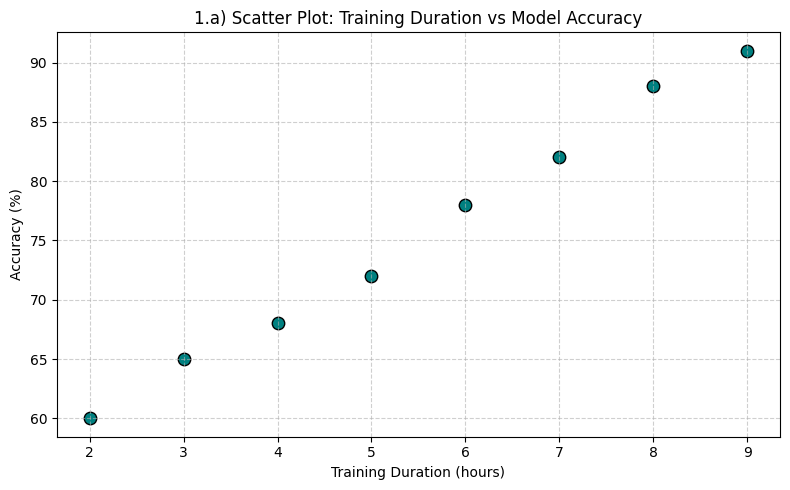

1.a) Karl Pearson Correlation Analysis:
  Pearson correlation coefficient (r) : 0.9974
  Coefficient of determination (r^2) : 0.9948

1.a) Interpretation:
  There is a very strong positive linear relationship between
  training time and model scores (r = 0.9974).
  About 99.48% of the variation in scores is
  explained by the training time.


In [2]:
# 1.a) Data: Training Duration (hrs) vs Accuracy (%) for 8 AI models
train_time = np.array([2, 3, 4, 5, 6, 7, 8, 9])
acc_scores = np.array([60, 65, 68, 72, 78, 82, 88, 91])

# i) Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(train_time, acc_scores, color='teal', s=80, edgecolor='black')
plt.title('1.a) Scatter Plot: Training Duration vs Model Accuracy')
plt.xlabel('Training Duration (hours)')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ii) Karl Pearson correlation coefficient
corr_coeff = np.corrcoef(train_time, acc_scores)[0, 1]
r_sq = corr_coeff ** 2

print("1.a) Karl Pearson Correlation Analysis:")
print(f"  Pearson correlation coefficient (r) : {corr_coeff:.4f}")
print(f"  Coefficient of determination (r^2) : {r_sq:.4f}")

# iii) Interpretation
if abs(corr_coeff) >= 0.8:
    level = "very strong"
elif abs(corr_coeff) >= 0.6:
    level = "strong"
elif abs(corr_coeff) >= 0.4:
    level = "moderate"
elif abs(corr_coeff) >= 0.2:
    level = "weak"
else:
    level = "very weak"
trend = "positive" if corr_coeff > 0 else "negative"

print("\n1.a) Interpretation:")
print(f"  There is a {level} {trend} linear relationship between")
print(f"  training time and model scores (r = {corr_coeff:.4f}).")
print(f"  About {r_sq*100:.2f}% of the variation in scores is")
print(f"  explained by the training time.")

#### 1.b) Linear Regression: GPU Expense vs AI Service Revenue

1.b) Linear Regression Model:
  Slope (beta1)     : 2.0200
  Intercept (beta0) : 0.7000
  Equation       : Revenue = 2.0200 * GPU_Expense + 0.7000


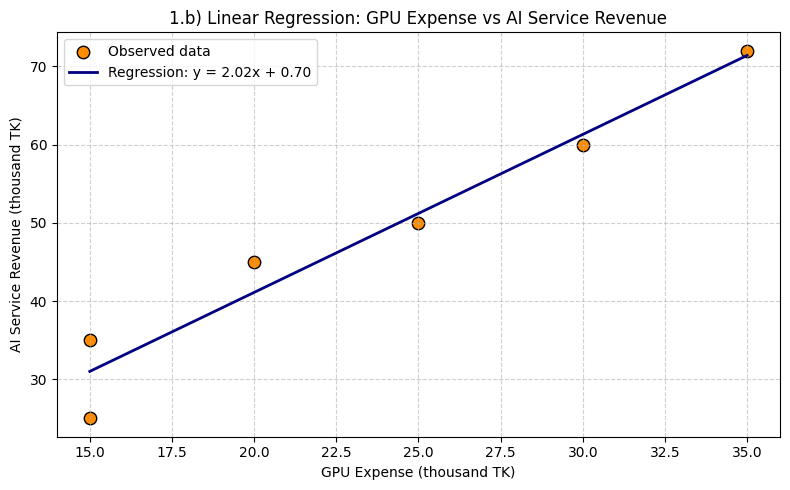


1.b) Prediction:
  When GPU Expense = 28 thousand TK,
  Predicted Revenue = 57.26 thousand TK

1.b) Interpretation of the Regression Model:
  - Correlation coefficient (r) : 0.9750
  - For every 1 thousand TK increase in GPU expense,
    revenue is expected to increase by 2.02 thousand TK.
  - The model explains 95.06% of the variation in revenue.


In [3]:
# 1.b) Data: GPU Expense and AI Service Revenue (in thousand TK)
gpu_expense = np.array([15, 15, 20, 25, 30, 35])
service_rev = np.array([25, 35, 45, 50, 60, 72])

# i) Develop linear regression model
beta1, beta0 = np.polyfit(gpu_expense, service_rev, 1)

print("1.b) Linear Regression Model:")
print(f"  Slope (beta1)     : {beta1:.4f}")
print(f"  Intercept (beta0) : {beta0:.4f}")
print(f"  Equation       : Revenue = {beta1:.4f} * GPU_Expense + {beta0:.4f}")

# ii) Plot the regression line with dataset
plt.figure(figsize=(8, 5))
plt.scatter(gpu_expense, service_rev, color='darkorange', s=80, edgecolor='black',
            label='Observed data')
plt.plot(gpu_expense, beta1 * gpu_expense + beta0, color='navy',
         linewidth=2, label=f'Regression: y = {beta1:.2f}x + {beta0:.2f}')
plt.title('1.b) Linear Regression: GPU Expense vs AI Service Revenue')
plt.xlabel('GPU Expense (thousand TK)')
plt.ylabel('AI Service Revenue (thousand TK)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# iii) Predict income when GPU cost = 28 thousand TK
gpu_val = 28
predicted_rev = beta1 * gpu_val + beta0
print("\n1.b) Prediction:")
print(f"  When GPU Expense = {gpu_val} thousand TK,")
print(f"  Predicted Revenue = {predicted_rev:.2f} thousand TK")

# iv) Interpretation
correlation = np.corrcoef(gpu_expense, service_rev)[0, 1]
print("\n1.b) Interpretation of the Regression Model:")
print(f"  - Correlation coefficient (r) : {correlation:.4f}")
print(f"  - For every 1 thousand TK increase in GPU expense,")
print(f"    revenue is expected to increase by {beta1:.2f} thousand TK.")
print(
    f"  - The model explains {correlation**2*100:.2f}% of the variation in revenue.")

#### 2.a) Comparing Variability in Two Development Teams

2.a) Measures of Variability:
--- Team Alpha ---
  Mean        : 12.50
  Median (Q2) : 12.50
  Q1          : 12.00
  Q3          : 13.00
  QD          : 0.50
  CQD         : 4.00%
  SD          : 1.05
  CV          : 8.39%

--- Team Beta ---
  Mean        : 13.83
  Median (Q2) : 13.50
  Q1          : 10.50
  Q3          : 17.25
  QD          : 3.38
  CQD         : 25.00%
  SD          : 4.67
  CV          : 33.73%


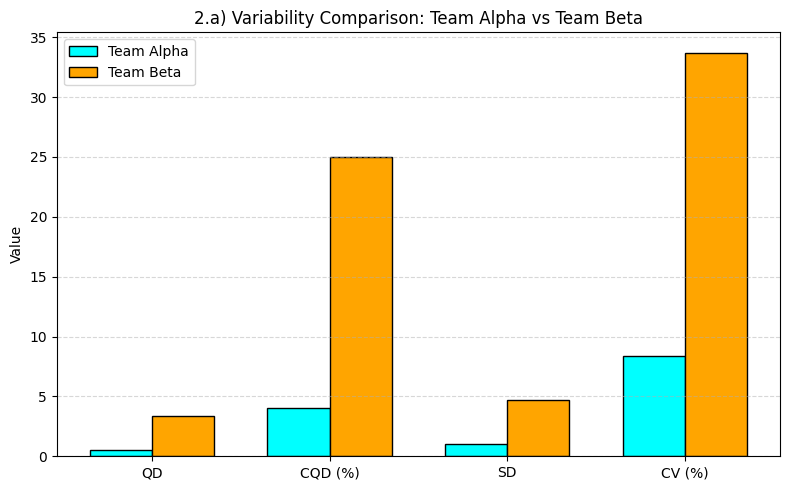


2.a) Consistency Decision:
  Team Alpha CV = 8.39%,  Team Beta CV = 33.73%
  => Team Alpha is more consistent (lower CV).

2.a) Importance of Consistency in Agile Development:
  - Predictable velocity enables reliable sprint planning.
  - Stable delivery improves stakeholder trust.
  - Reduces risk of missed deadlines and burnout.
  - Makes burndown/burnup charts smoother and easier to read.
  - Facilitates continuous improvement through less variance to analyze.


In [4]:
# 2.a) Sprint completion times for Team Alpha and Team Beta
team_alpha = np.array([12, 13, 12, 11, 14, 13])
team_beta = np.array([8, 10, 12, 15, 18, 20])

def compute_dispersion(label, values):
    q1, med, q3 = np.percentile(values, [25, 50, 75])
    q_diff = (q3 - q1) / 2
    coeff_q_diff = (q_diff / med) * 100
    st_dev = np.std(values, ddof=1)
    avg = np.mean(values)
    coeff_var = (st_dev / avg) * 100
    print(f"--- {label} ---")
    print(f"  Mean        : {avg:.2f}")
    print(f"  Median (Q2) : {med:.2f}")
    print(f"  Q1          : {q1:.2f}")
    print(f"  Q3          : {q3:.2f}")
    print(f"  QD          : {q_diff:.2f}")
    print(f"  CQD         : {coeff_q_diff:.2f}%")
    print(f"  SD          : {st_dev:.2f}")
    print(f"  CV          : {coeff_var:.2f}%")
    return coeff_var, st_dev, q_diff, coeff_q_diff

print("2.a) Measures of Variability:")
cv_a, sd_a, qd_a, cqd_a = compute_dispersion("Team Alpha", team_alpha)
print()
cv_b, sd_b, qd_b, cqd_b = compute_dispersion("Team Beta", team_beta)

# Bar chart comparing the variability measures
metric_labels = ['QD', 'CQD (%)', 'SD', 'CV (%)']
pos = np.arange(len(metric_labels))
bar_width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(pos - bar_width/2, [qd_a, cqd_a, sd_a, cv_a], bar_width,
        label='Team Alpha', color='cyan', edgecolor='black')
plt.bar(pos + bar_width/2, [qd_b, cqd_b, sd_b, cv_b], bar_width,
        label='Team Beta', color='orange', edgecolor='black')
plt.xticks(pos, metric_labels)
plt.ylabel('Value')
plt.title('2.a) Variability Comparison: Team Alpha vs Team Beta')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

# ii) Determine which team is more consistent
consistent_team = "Team Alpha" if cv_a < cv_b else "Team Beta"
print("\n2.a) Consistency Decision:")
print(f"  Team Alpha CV = {cv_a:.2f}%,  Team Beta CV = {cv_b:.2f}%")
print(f"  => {consistent_team} is more consistent (lower CV).")

# iii) Importance of consistency in Agile
print("\n2.a) Importance of Consistency in Agile Development:")
print("  - Predictable velocity enables reliable sprint planning.")
print("  - Stable delivery improves stakeholder trust.")
print("  - Reduces risk of missed deadlines and burnout.")
print("  - Makes burndown/burnup charts smoother and easier to read.")
print("  - Facilitates continuous improvement through less variance to analyze.")

#### 2.b) IoT Soil Moisture Data: Box Plot and Outlier Analysis

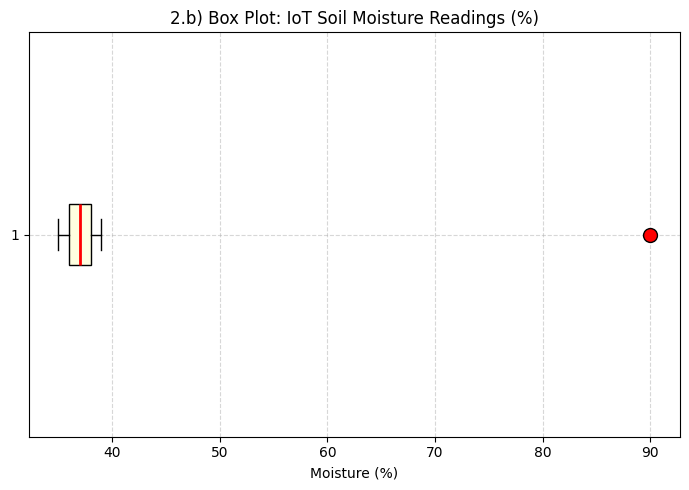

2.b) Outlier Detection (IQR Method):
  Q1        : 36.0
  Q2 (Med)  : 37.0
  Q3        : 38.0
  IQR       : 2.0
  Lower Fence: 33.0
  Upper Fence: 41.0
  Outliers detected: [90]

2.b) Interpretation:
  The reading 90% is a clear outlier - it is far above the upper
  fence (41%) of the IQR method. In an IoT smart-agriculture system,
  such an abnormal reading could trigger false irrigation decisions,
  waste water, or mask actual sensor faults. Pre-processing with
  outlier detection is essential before feeding data to the decision system.


In [5]:
# 2.b) IoT soil sensor readings (10 readings)
moisture_readings = np.array([35, 36, 37, 35, 38, 39, 36, 37, 90, 38])

# i) Draw a box plot
plt.figure(figsize=(7, 5))
plt.boxplot(moisture_readings, vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightyellow', edgecolor='black'),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='red',
                            markersize=10, markeredgecolor='black'))
plt.title('2.b) Box Plot: IoT Soil Moisture Readings (%)')
plt.xlabel('Moisture (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ii) Detect anomalies using the IQR method
q1_val, q2_val, q3_val = np.percentile(moisture_readings, [25, 50, 75])
iqr_val = q3_val - q1_val
low_fence = q1_val - 1.5 * iqr_val
high_fence = q3_val + 1.5 * iqr_val
outliers = moisture_readings[(moisture_readings < low_fence) | (moisture_readings > high_fence)]

print("2.b) Outlier Detection (IQR Method):")
print(f"  Q1        : {q1_val}")
print(f"  Q2 (Med)  : {q2_val}")
print(f"  Q3        : {q3_val}")
print(f"  IQR       : {iqr_val}")
print(f"  Lower Fence: {low_fence}")
print(f"  Upper Fence: {high_fence}")
print(f"  Outliers detected: {outliers.tolist()}")

# iii) Interpretation
print("\n2.b) Interpretation:")
print("  The reading 90% is a clear outlier - it is far above the upper")
print("  fence (41%) of the IQR method. In an IoT smart-agriculture system,")
print("  such an abnormal reading could trigger false irrigation decisions,")
print("  waste water, or mask actual sensor faults. Pre-processing with")
print("  outlier detection is essential before feeding data to the decision system.")